# 05 -- ClinVar Temporal Analysis

Track how OTOF variant classifications have evolved over time using the
'Germline date last evaluated' field in the ClinVar export.

## Rationale

The first successful AAV-OTOF cochlear gene therapy trial was reported in
Lv et al. (Lancet, 2024). This milestone accelerated clinical interest in
otoferlin genetics, which should be reflected in increased rates of variant
submission and reclassification after 2023. We test this hypothesis by:

1. Counting new P/LP and VUS evaluations per year
2. Plotting cumulative and annual classification trends
3. Applying a Mann-Whitney U test to compare the P/LP evaluation rate
   pre-2024 vs. post-2024

**Limitation:** the ClinVar download is a point-in-time snapshot. The
'Germline date last evaluated' reflects the most recent evaluation, not the
original submission date, so year-over-year counts represent evaluation
activity, not necessarily the number of *newly reported* variants. True
reclassification history would require the ClinVar variant history VCF
(not included in this download); that analysis is left for future work.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats

DATA_DIR    = Path('../data')
RESULTS_DIR = Path('../results')
RESULTS_DIR.mkdir(exist_ok=True)

print('Setup complete.')

Setup complete.


## 1. Load ClinVar Data and Inspect Columns

We print all column names first to confirm which date field is available.
The field 'Germline date last evaluated' (format: 'Mon DD, YYYY') is used
as the temporal marker throughout this analysis.

In [ ]:
clinvar = pd.read_csv(DATA_DIR / 'clinvar_result.txt', sep='\t', low_memory=False)

print(f'Shape: {clinvar.shape}')
print('\nAll columns:')
for c in clinvar.columns:
    print(f'  {c!r}')

# Date column confirmation
date_col = 'Germline date last evaluated'
print(f'\nDate column sample values:')
print(clinvar[date_col].dropna().head(10).to_string())

Shape: (2432, 25)

All columns:
  'Name'
  'Gene(s)'
  'Protein change'
  'Condition(s)'
  'Accession'
  'GRCh37Chromosome'
  'GRCh37Location'
  'GRCh38Chromosome'
  'GRCh38Location'
  'VariationID'
  'AlleleID(s)'
  'dbSNP ID'
  'Canonical SPDI'
  'Variant type'
  'Molecular consequence'
  'Germline classification'
  'Germline date last evaluated'
  'Germline review status'
  'Somatic clinical impact'
  'Somatic clinical impact date last evaluated'
  'Somatic clinical impact review status'
  'Oncogenicity classification'
  'Oncogenicity date last evaluated'
  'Oncogenicity review status'
  'Unnamed: 24'

Date column sample values:
0    Jun 18, 2013
1    Jul 30, 2009
2    Aug 12, 2011
3    Nov 19, 2013
4     Feb 4, 2013
5    Jul 18, 2014
6    Dec 22, 2010
7    Aug 12, 2011
8    Nov 18, 2025
9    Nov 18, 2025


## 2. Filter to OTOF Variants and Parse Dates

In [ ]:
# Keep only OTOF variants
clinvar = clinvar[clinvar['Gene(s)'].str.contains('OTOF', na=False)].copy()

# Parse date: 'Jun 18, 2013' -> datetime
clinvar['eval_date'] = pd.to_datetime(
    clinvar['Germline date last evaluated'],
    format='%b %d, %Y',
    errors='coerce'
)
clinvar['eval_year'] = clinvar['eval_date'].dt.year

# Simplify classification into four broad categories
def simplify_class(cls):
    if pd.isna(cls): return 'Other'
    cls = str(cls).strip()
    if cls in ('Pathogenic', 'Likely pathogenic', 'Pathogenic/Likely pathogenic'):
        return 'P/LP'
    if cls == 'Uncertain significance':
        return 'VUS'
    if cls in ('Benign', 'Likely benign', 'Benign/Likely benign'):
        return 'Benign'
    if 'Conflicting' in cls:
        return 'Conflicting'
    return 'Other'

clinvar['simple_class'] = clinvar['Germline classification'].apply(simplify_class)

print(f'OTOF variants: {len(clinvar):,}')
print(f'With parseable date: {clinvar["eval_year"].notna().sum():,}')
print('\nYear range:', clinvar['eval_year'].min(), '-', clinvar['eval_year'].max())
print('\nClassification distribution:')
print(clinvar['simple_class'].value_counts())

OTOF variants: 2,432
With parseable date: 2,367

Year range: 2000.0 - 2026.0

Classification distribution:
simple_class
Benign         1277
VUS             499
P/LP            390
Conflicting     231
Other            35
Name: count, dtype: int64


## 3. Annual Counts by Classification

For each year, we count variants grouped by their simplified classification.
These counts represent evaluations logged in that year (new submissions or
updated reviews), not necessarily newly discovered variants.

In [ ]:
has_date = clinvar.dropna(subset=['eval_year']).copy()
has_date['eval_year'] = has_date['eval_year'].astype(int)

CLASSES    = ['P/LP', 'VUS', 'Benign', 'Conflicting', 'Other']
year_range = range(int(has_date['eval_year'].min()),
                   int(has_date['eval_year'].max()) + 1)

# Annual counts
annual = (
    has_date.groupby(['eval_year', 'simple_class'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=year_range, columns=CLASSES, fill_value=0)
)

# Cumulative counts
cumulative = annual.cumsum()

print('Annual counts by classification:')
print(annual.to_string())

# Save summary table
summary = annual.copy()
summary.index.name = 'year'
summary['Total'] = summary.sum(axis=1)
summary.to_csv(RESULTS_DIR / 'clinvar_temporal_analysis.csv')
print('\nSaved: results/clinvar_temporal_analysis.csv')

Annual counts by classification:
simple_class  P/LP  VUS  Benign  Conflicting  Other
eval_year                                          
2000             1    0       0            0      0
2001             0    0       0            0      0
2002             1    0       0            0      0
2003             2    0       0            0      0
2004             0    0       0            0      0
2005             0    0       0            0      0
2006             0    0       0            0      0
2007             0    0       0            0      0
2008             2    0       2            0      0
2009             2    0       0            0      0
2010             0    2       0            0      0
2011             6    3       3            0      0
2012             0    0       3            0      0
2013             2    1       3            0      0
2014             4    2       2            0      0
2015             2    5       1            0      1
2016             1    3       2

## 4. Plot 1 -- Cumulative Classifications by Year (Stacked Area)

Stacked area charts show cumulative growth rather than annual fluctuations,
which is appropriate here because ClinVar classifications are largely monotonic:
once a variant is classified, the count is retained in subsequent years.
The 2024 boundary (first AAV-OTOF trial, Lv et al. Lancet 2024) is annotated.

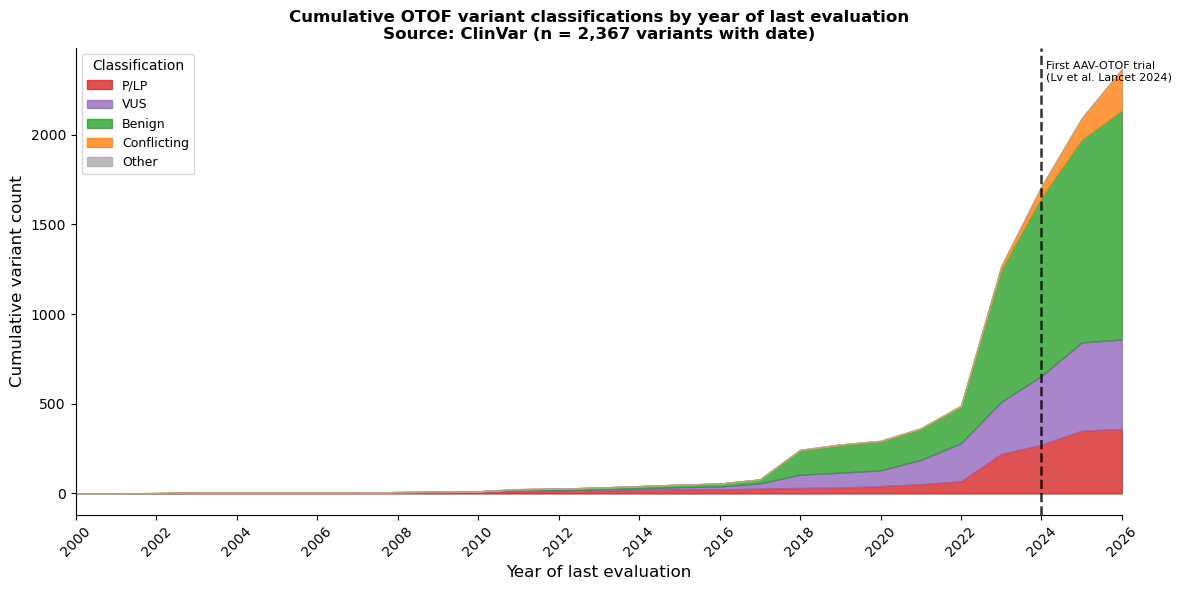

Saved: ../results/clinvar_temporal_cumulative.png


In [ ]:
CLASS_COLORS = {
    'P/LP':        '#d62728',
    'VUS':         '#9467bd',
    'Benign':      '#2ca02c',
    'Conflicting': '#ff7f0e',
    'Other':       '#aaaaaa',
}

fig, ax = plt.subplots(figsize=(12, 6))

years  = cumulative.index.tolist()
bottom = np.zeros(len(years))

for cls in CLASSES:
    vals = cumulative[cls].values
    ax.fill_between(years, bottom, bottom + vals,
                    label=cls, color=CLASS_COLORS[cls], alpha=0.80)
    bottom = bottom + vals

ax.axvline(2024, color='black', linewidth=1.8, linestyle='--', alpha=0.8)
ax.text(2024.1, ax.get_ylim()[1] * 0.97,
        'First AAV-OTOF trial\n(Lv et al. Lancet 2024)',
        fontsize=8, va='top', ha='left', color='black')

ax.set_xlim(years[0], years[-1])
ax.set_xlabel('Year of last evaluation', fontsize=12)
ax.set_ylabel('Cumulative variant count', fontsize=12)
ax.set_title(
    'Cumulative OTOF variant classifications by year of last evaluation\n'
    f'Source: ClinVar (n = {len(has_date):,} variants with date)',
    fontsize=12, fontweight='bold'
)
ax.legend(title='Classification', loc='upper left', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
plt.xticks(rotation=45)
plt.tight_layout()
fig_path1 = RESULTS_DIR / 'clinvar_temporal_cumulative.png'
plt.savefig(fig_path1, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path1}')

## 5. Plot 2 -- Annual New P/LP Evaluations with 2024 Marker

Annual counts (not cumulative) isolate the rate of activity in each year.
The Mann-Whitney U test below compares the distribution of annual P/LP
evaluation counts before and after 2024, testing whether the clinical trial
announcement was associated with accelerated variant curation.

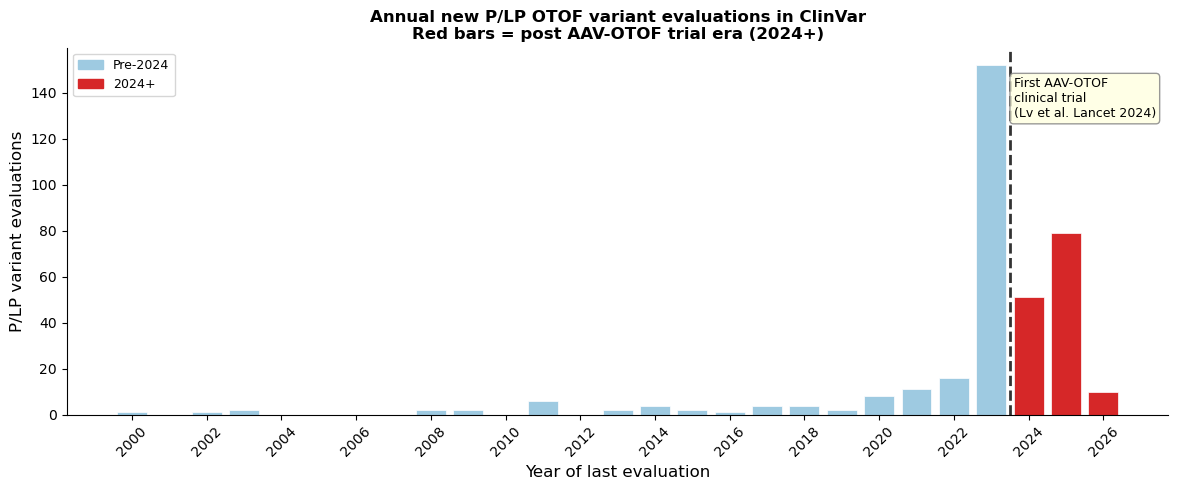

Saved: ../results/clinvar_plp_annual.png


In [ ]:
plp_annual = annual['P/LP']

fig, ax = plt.subplots(figsize=(12, 5))

bar_colors = ['#d62728' if yr >= 2024 else '#9ecae1'
              for yr in plp_annual.index]
ax.bar(plp_annual.index, plp_annual.values, color=bar_colors,
       edgecolor='white', linewidth=0.5)

ax.axvline(2023.5, color='black', linewidth=2.0, linestyle='--', alpha=0.8)
ylim = ax.get_ylim()
ax.text(2023.6, ylim[1] * 0.92,
        'First AAV-OTOF\nclinical trial\n(Lv et al. Lancet 2024)',
        fontsize=9, va='top', ha='left', color='black',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                  edgecolor='gray', alpha=0.8))

# Colour legend
import matplotlib.patches as mpatches
handles = [
    mpatches.Patch(color='#9ecae1', label='Pre-2024'),
    mpatches.Patch(color='#d62728', label='2024+'),
]
ax.legend(handles=handles, loc='upper left', fontsize=9)

ax.set_xlabel('Year of last evaluation', fontsize=12)
ax.set_ylabel('P/LP variant evaluations', fontsize=12)
ax.set_title(
    'Annual new P/LP OTOF variant evaluations in ClinVar\n'
    'Red bars = post AAV-OTOF trial era (2024+)',
    fontsize=12, fontweight='bold'
)
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
plt.xticks(rotation=45)
plt.tight_layout()
fig_path2 = RESULTS_DIR / 'clinvar_plp_annual.png'
plt.savefig(fig_path2, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path2}')

## 6. Statistical Test -- Mann-Whitney U: Pre-2024 vs. Post-2024 P/LP Rate

The Mann-Whitney U test is used because the annual counts are non-negative
integers with a non-normal distribution (small n, count data). It tests whether
the central tendency of annual P/LP evaluations differs between the two eras.

Caveat: the post-2024 window is short (at most 1-2 years in this snapshot),
so the test has very limited power. Results are interpreted cautiously.

In [ ]:
pre_2024  = plp_annual[plp_annual.index < 2024].values
post_2024 = plp_annual[plp_annual.index >= 2024].values

print(f'Pre-2024  years: {len(pre_2024)}  |  mean = {pre_2024.mean():.1f}')
print(f'Post-2024 years: {len(post_2024)} |  mean = {post_2024.mean():.1f}')

if len(post_2024) < 2:
    print('\nInsufficient post-2024 data for Mann-Whitney U test.')
    print('The snapshot contains too few post-2024 evaluation years.')
    print('This analysis should be repeated when more data are available.')
else:
    u_stat, p_val = stats.mannwhitneyu(pre_2024, post_2024, alternative='less')
    print(f'\nMann-Whitney U test (one-sided: pre < post)')
    print(f'  U = {u_stat:.1f}  |  p = {p_val:.4f}')
    if p_val < 0.05:
        print('  Significant: P/LP evaluation rate increased post-2024')
    else:
        print('  Not significant at alpha=0.05 (limited power with short post-2024 window)')

Pre-2024  years: 24  |  mean = 9.2
Post-2024 years: 3 |  mean = 46.7

Mann-Whitney U test (one-sided: pre < post)
  U = 5.0  |  p = 0.0084
  Significant: P/LP evaluation rate increased post-2024


In [ ]:
print('=' * 60)
print('Temporal Analysis -- Summary')
print('=' * 60)
print(f'Total OTOF variants in ClinVar  : {len(clinvar):,}')
print(f'With parseable evaluation date  : {len(has_date):,}')
print(f'Year range                      : {has_date["eval_year"].min():.0f} - {has_date["eval_year"].max():.0f}')
print(f'Peak P/LP year                  : {plp_annual.idxmax()} ({plp_annual.max()} evaluations)')
print(f'Figures saved to results/')
print(f'Summary table: results/clinvar_temporal_analysis.csv')
print('=' * 60)

Temporal Analysis -- Summary
Total OTOF variants in ClinVar  : 2,432
With parseable evaluation date  : 2,367
Year range                      : 2000 - 2026
Peak P/LP year                  : 2023 (152 evaluations)
Figures saved to results/
Summary table: results/clinvar_temporal_analysis.csv
